# Checkpoint 2 - Nutrient Uptake Simulation of Part 2 Plant Growth Module 
This notebook builds the nitrogen uptake module fitting a global Michaelis–Menten uptake isotherm and saves fitted uptake parameters for later integration.

In [70]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [71]:
# CONFIG
EXCEL_PATH = "/Users/yuming/Desktop/Folders/VerticalFarm/NPK.CrossT.All.xlsx"
SHEET_NAME = "ModSample"
HEADER_ROW = 1  # Excel row 2 as header in pandas

OUTPUT_DIR = Path("checkpoint2_uptake_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("default")


In [72]:
def michaelis_menten(n, umax, km):
    n = np.asarray(n, dtype=float)
    n = np.clip(n, 0.0, None)
    return umax * n / (km + n + 1e-12)

def metrics_dict(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
    }

def normalize_category(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().upper()
    if s in {"N", "N-LIMITED", "N LIMITED"}:
        return "N"
    if s in {"P", "P-LIMITED", "P LIMITED"}:
        return "P"
    if s in {"K", "K-LIMITED", "K LIMITED"}:
        return "K"
    if s in {"MSS", "SUFFICIENT", "NUTRIENT SUFFICIENT", "CONTROL"}:
        return "MSS"
    return s

def find_first_existing(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None


In [73]:
sample_df = pd.read_excel(
    EXCEL_PATH,
    sheet_name=SHEET_NAME,
    header=HEADER_ROW
)

print("Columns:")
print(sample_df.columns.tolist())
print("\nShape:", sample_df.shape)
sample_df.head()


Columns:
['ModRig #', 'Limiting Nutrient', 'Treatment %', 'Round', 'Treatment', 'Treatment mg/L N', 'Treatment mg/L P', 'Treatment mg/L K', 'Rig', 'Growth Day', 'Pre/Post', 'Harvest Period', 'Concat (SampleAnalysis)', '# of plants', 'Lifetime Avg [N] (mg/L)', 'Lifetime Avg [P] (mg/L)', 'Lifetime Avg [K] (mg/L)', 'Lifetime Avg U_N', 'U_N SD Quantified', 'U_N Screening', 'N Screening Reason', 'Lifetime Avg U_P', 'U_P SD Quantified', 'U_P Screening', 'P Screening Reason', 'Lifetime Avg U_K', 'U_K SD Quantified', 'U_K Screening', 'K Screening Reason', 'Lifetime Average [Ca]', 'Lifetime Average [Mg]', 'Lifetime Average [S]', 'Lifetime Average [Fe]', 'Lifetime Avg U_Ca', 'U_Ca SD Quantified', 'U_Ca Screening', 'Ca Screening Reason', 'Lifetime Avg U_Mg', 'U_Mg SD Quantified', 'U_Mg Screening', 'Mg Screening Reason', 'Lifetime Avg U_S', 'U_S SD Quantified', 'U_S Screening', 'S Screening Reason', 'Lifetime Avg U_Fe', 'U_Fe SD Quantified', 'U_Fe Screening', 'Fe Screening Reason', 'Inst [N]', 'In

,ModRig #,Limiting Nutrient,Treatment %,Round,Treatment,Treatment mg/L N,Treatment mg/L P,Treatment mg/L K,Rig,Growth Day,...,U_Fe SD Quantified,U_Fe Screening,Fe Screening Reason,Inst [N],Inst [P],Inst [K],Sample Period Avg [N],Sample Period Avg [P],Sample Period Avg [K],Concat (Sample to Plant)
0,1,MSS,1.0,R22,R22,132.0,31.0,210.0,N1,0,...,NaN,Screen,No Data,99.300000,18.964982,119.093681,NaN,NaN,NaN,R22-0-N1
1,2,MSS,1.0,R22,R22,132.0,31.0,210.0,N2,0,...,0.0,Screen,No Data,127.000000,23.786297,152.491699,NaN,NaN,NaN,R22-0-N2
2,3,MSS,1.0,R22,R22,132.0,31.0,210.0,N3,0,...,0.0,Screen,No Data,129.000000,24.415922,153.059816,NaN,NaN,NaN,R22-0-N3
3,4,MSS,1.0,R22,R22,132.0,31.0,210.0,S1,0,...,0.0,Screen,No Data,115.000000,22.474284,139.983854,NaN,NaN,NaN,R22-0-S1
4,5,MSS,1.0,R22,R22,132.0,31.0,210.0,S2,0,...,0.0,Screen,No Data,106.333333,19.201870,125.792895,NaN,NaN,NaN,R22-0-S2


In [74]:
# Candidate column names based on dataset
TREATMENT_COL_CANDIDATES = ["Treatment", "Treatment ID", "Treatment Name"]
CATEGORY_COL_CANDIDATES = ["Limiting Nutrient", "Category"]
N_COL_CANDIDATES = ["Lifetime Avg [N] (mg/L)", "Lifetime Avg N", "N", "Nitrogen"]
UPTAKE_COL_CANDIDATES = ["Lifetime Avg U_N", "U_N", "Avg U_N", "Uptake N"]
SCREEN_COL_CANDIDATES = ["U_N Screening", "Screening", "Uptake Screening"]

treatment_col = find_first_existing(sample_df.columns, TREATMENT_COL_CANDIDATES)
category_col = find_first_existing(sample_df.columns, CATEGORY_COL_CANDIDATES)
n_col = find_first_existing(sample_df.columns, N_COL_CANDIDATES)
uptake_col = find_first_existing(sample_df.columns, UPTAKE_COL_CANDIDATES)
screen_col = find_first_existing(sample_df.columns, SCREEN_COL_CANDIDATES)

print("Treatment column:", treatment_col)
print("Category column :", category_col)
print("N column        :", n_col)
print("Uptake column   :", uptake_col)
print("Screen column   :", screen_col)


Treatment column: Treatment
Category column : Limiting Nutrient
N column        : Lifetime Avg [N] (mg/L)
Uptake column   : Lifetime Avg U_N
Screen column   : U_N Screening


In [75]:
## Build filtered global uptake dataset from `ModSample` data

In [76]:
if treatment_col is None:
    raise ValueError("Could not find a treatment column in ModSample.")
if category_col is None:
    raise ValueError("Could not find a category / limiting nutrient column in ModSample.")
if n_col is None:
    raise ValueError("Could not find nitrogen concentration column in ModSample.")
if uptake_col is None:
    raise ValueError("Could not find uptake column in ModSample.")

uptake_df = sample_df.copy()

uptake_df["Treatment"] = uptake_df[treatment_col].astype(str).str.strip()
uptake_df["Category"] = uptake_df[category_col].apply(normalize_category)
uptake_df["N"] = pd.to_numeric(uptake_df[n_col], errors="coerce")
uptake_df["U_obs"] = pd.to_numeric(uptake_df[uptake_col], errors="coerce")

if screen_col is not None:
    uptake_df["screen_flag"] = uptake_df[screen_col].astype(str).str.strip().str.upper()
    uptake_df = uptake_df[uptake_df["screen_flag"] == "SCREEN"].copy()

# Filter out NaN and 0 values
uptake_df = uptake_df.dropna(subset=["Treatment", "Category", "N", "U_obs"]).copy()
uptake_df = uptake_df[np.isfinite(uptake_df["N"]) & np.isfinite(uptake_df["U_obs"])].copy()
uptake_df = uptake_df[(uptake_df["N"] > 0) & (uptake_df["U_obs"] > 0)].copy()

uptake_df = uptake_df.sort_values(["Category", "Treatment", "N"]).reset_index(drop=True)

print("Filtered uptake dataset shape:", uptake_df.shape)
uptake_df.head(20)


Filtered uptake dataset shape: (48, 60)


,ModRig #,Limiting Nutrient,Treatment %,Round,Treatment,Treatment mg/L N,Treatment mg/L P,Treatment mg/L K,Rig,Growth Day,...,Inst [P],Inst [K],Sample Period Avg [N],Sample Period Avg [P],Sample Period Avg [K],Concat (Sample to Plant),Category,N,U_obs,screen_flag
0,1547,K,0.200,R23,R23N,NaN,NaN,42.0,N2,14,...,10.747231,7.171967,89.800000,15.809184,18.556669,R23-14-N2,K,117.075000,119.326777,SCREEN
1,1616,K,0.500,R23,R23S,NaN,NaN,105.0,S2,14,...,12.118365,33.255532,87.500000,16.482686,53.613169,R23-14-S2,K,105.575000,114.257891,SCREEN
2,1615,K,0.500,R23,R23S,NaN,NaN,105.0,S1,14,...,12.236594,37.592782,93.600000,16.315880,55.163613,R23-14-S1,K,116.400000,96.093816,SCREEN
3,1706,K,0.100,R24,R24,NaN,NaN,21.0,N2,14,...,2.229614,0.940074,40.300000,4.263201,1.064059,R24-14-N2,K,82.375000,103.308902,SCREEN
4,1705,K,0.100,R24,R24,NaN,NaN,21.0,N1,14,...,3.779941,1.048836,73.600000,7.448662,3.763750,R24-14-N1,K,92.850000,102.675105,SCREEN
5,1707,K,0.100,R24,R24,NaN,NaN,21.0,N3,14,...,2.504512,0.986578,77.700000,6.328978,1.799104,R24-14-N3,K,101.550000,103.308902,SCREEN
6,1709,K,0.100,R24,R24,NaN,NaN,21.0,S2,14,...,2.375343,1.047084,83.050000,4.799184,2.253448,R24-14-S2,K,108.100000,134.048053,SCREEN
7,1845,K,0.040,R25,R25,NaN,NaN,13.0,N3,14,...,13.151653,3.553787,96.900000,15.818396,4.846538,R25-14-N3,K,105.157143,91.960067,SCREEN
8,1848,K,0.040,R25,R25,NaN,NaN,13.0,S3,14,...,13.319835,3.540625,100.400000,16.963013,3.912087,R25-14-S3,K,110.485714,113.855321,SCREEN
9,1844,K,0.040,R25,R25,NaN,NaN,13.0,N2,14,...,15.266688,4.182787,106.800000,17.721190,5.643342,R25-14-N2,K,121.628571,99.868181,SCREEN


In [77]:
summary = (
    uptake_df.groupby(["Category", "Treatment"])
    .agg(
        n_rows=("U_obs", "size"),
        N_mean=("N", "mean"),
        N_min=("N", "min"),
        N_max=("N", "max"),
        U_mean=("U_obs", "mean"),
        U_min=("U_obs", "min"),
        U_max=("U_obs", "max"),
    )
    .reset_index()
)

summary


,Category,Treatment,n_rows,N_mean,N_min,N_max,U_mean,U_min,U_max
0,K,R23N,1,117.075000,117.075000,117.075000,119.326777,119.326777,119.326777
1,K,R23S,2,110.987500,105.575000,116.400000,105.175854,96.093816,114.257891
2,K,R24,4,96.218750,82.375000,108.100000,110.835240,102.675105,134.048053
3,K,R25,3,112.423810,105.157143,121.628571,101.894523,91.960067,113.855321
4,K,R34,2,123.192500,122.325000,124.060000,249.724178,175.653439,323.794917
5,MSS,R22,3,117.770833,114.987500,120.375000,104.687234,89.557847,128.549019
6,N,R09N,2,16.674881,15.532857,17.816905,51.055147,46.413086,55.697207
7,N,R09S,2,53.975000,53.971429,53.978571,72.332148,68.362110,76.302185
8,N,R11n12,5,257.310434,219.825000,271.242424,293.239204,205.801462,439.061518
9,N,R13,4,5.780088,4.819242,6.378922,26.322182,25.330750,27.427899


## Fit one global Michaelis–Menten uptake model

In [78]:
x = uptake_df["N"].values.astype(float)
y = uptake_df["U_obs"].values.astype(float)

p0 = [max(np.nanpercentile(y, 90), 1e-6), max(np.nanmedian(x), 1e-6)]
bounds = ([1e-8, 1e-8], [1e6, 1e6])

params_global, cov_global = curve_fit(
    michaelis_menten,
    x,
    y,
    p0=p0,
    bounds=bounds,
    maxfev=100000
)

umax_fit, km_fit = params_global
y_pred = michaelis_menten(x, umax_fit, km_fit)
met_global = metrics_dict(y, y_pred)

print("Global Michaelis–Menten fit")
print(f"Umax = {umax_fit:.6f}")
print(f"Km   = {km_fit:.6f}")
print(met_global)


Global Michaelis–Menten fit
Umax = 999999.878741
Km   = 899654.359566
{'R2': 0.5901152581333049, 'MAE': 41.98293243131653, 'RMSE': np.float64(56.970152283470334)}


In [79]:
fitted_uptake_params = {
    "global": {
        "Umax": float(umax_fit),
        "Km": float(km_fit),
        "metrics": {k: float(v) for k, v in met_global.items()},
        "x_col": n_col,
        "y_col": uptake_col,
        "sheet_name": SHEET_NAME,
        "screen_col": screen_col,
    }
}

with open(OUTPUT_DIR / "fitted_uptake_params_global.json", "w") as f:
    json.dump(fitted_uptake_params, f, indent=2)

print("Saved:", OUTPUT_DIR / "fitted_uptake_params_global.json")


Saved: checkpoint2_uptake_outputs/fitted_uptake_params_global.json


## Nutrient Uptake isotherm plots

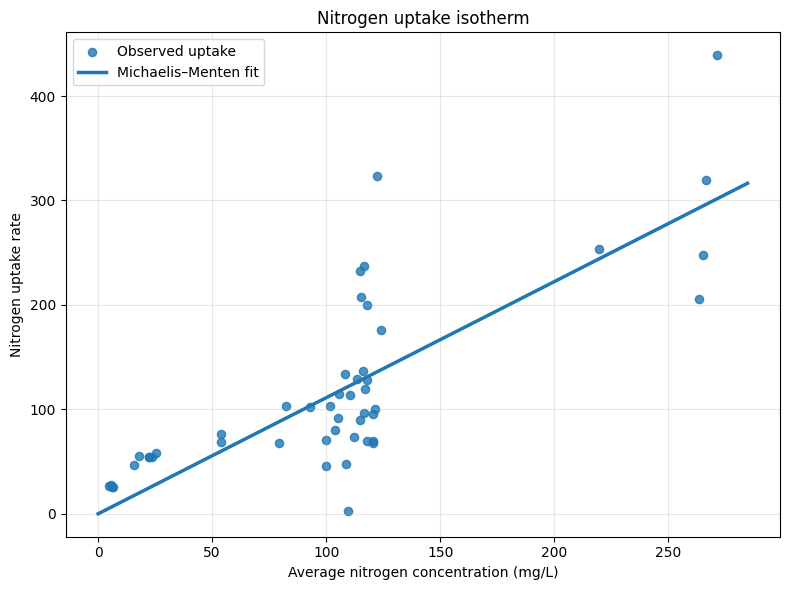

In [80]:
x_grid = np.linspace(0, max(uptake_df["N"].max() * 1.05, 1.0), 400)
y_grid = michaelis_menten(x_grid, umax_fit, km_fit)

plt.figure(figsize=(8, 6))
plt.scatter(
    uptake_df["N"],
    uptake_df["U_obs"],
    s=35,
    alpha=0.8,
    label="Observed uptake"
)
plt.plot(
    x_grid,
    y_grid,
    linewidth=2.5,
    label="Michaelis–Menten fit"
)

plt.xlabel("Average nitrogen concentration (mg/L)")
plt.ylabel("Nitrogen uptake rate")
plt.title("Nitrogen uptake isotherm")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

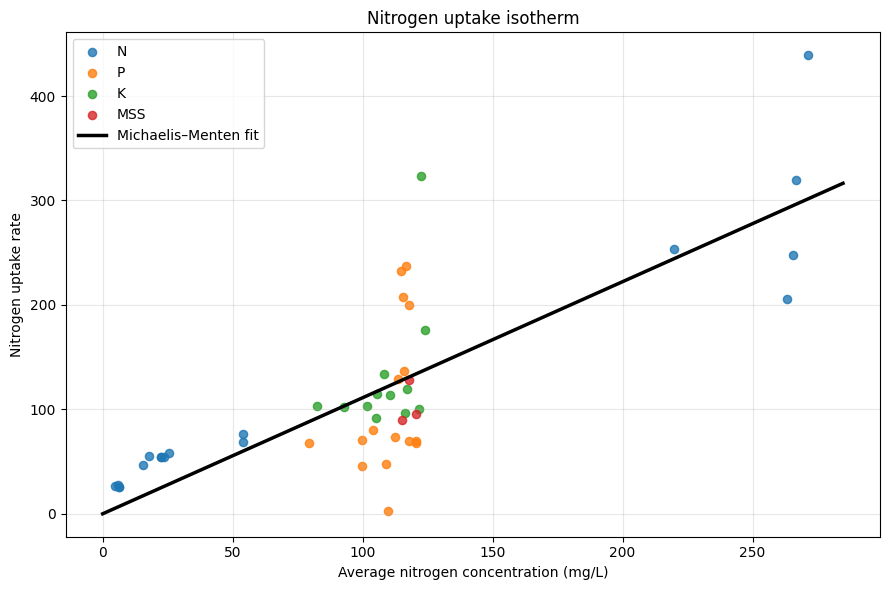

In [81]:
category_order = ["N", "P", "K", "MSS"]
present_categories = [c for c in category_order if c in uptake_df["Category"].unique()]
other_categories = [c for c in uptake_df["Category"].unique() if c not in present_categories]
plot_categories = present_categories + sorted(other_categories)

plt.figure(figsize=(9, 6))
for cat in plot_categories:
    sub = uptake_df[uptake_df["Category"] == cat]
    plt.scatter(
        sub["N"],
        sub["U_obs"],
        s=35,
        alpha=0.8,
        label=cat
    )

plt.plot(
    x_grid,
    y_grid,
    color="black",
    linewidth=2.5,
    label="Michaelis–Menten fit"
)

plt.xlabel("Average nitrogen concentration (mg/L)")
plt.ylabel("Nitrogen uptake rate")
plt.title("Nitrogen uptake isotherm")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

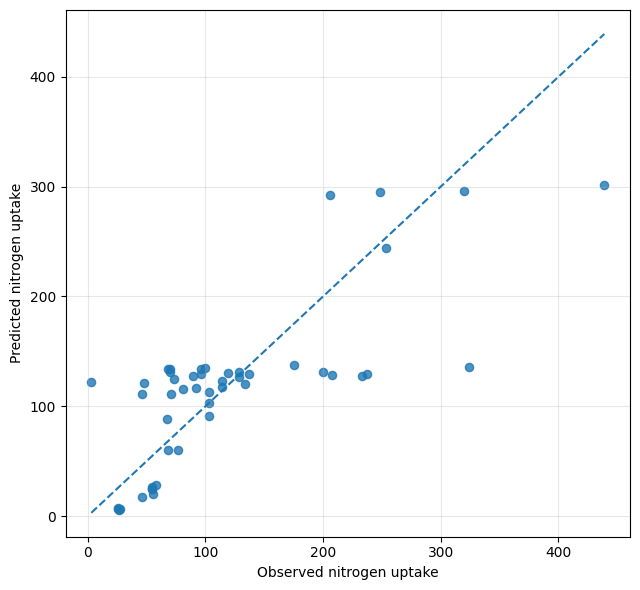

Observed vs predicted metrics:
{'R2': 0.5901152581333049, 'MAE': 41.98293243131653, 'RMSE': np.float64(56.970152283470334)}


In [82]:
plt.figure(figsize=(6.5, 6))
plt.scatter(y, y_pred, s=35, alpha=0.8)

xy_min = min(np.min(y), np.min(y_pred))
xy_max = max(np.max(y), np.max(y_pred))
plt.plot([xy_min, xy_max], [xy_min, xy_max], linestyle="--", linewidth=1.5)

plt.xlabel("Observed nitrogen uptake")
plt.ylabel("Predicted nitrogen uptake")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Observed vs predicted metrics:")
print(met_global)


## Overall time-series scatter with simulated scatter

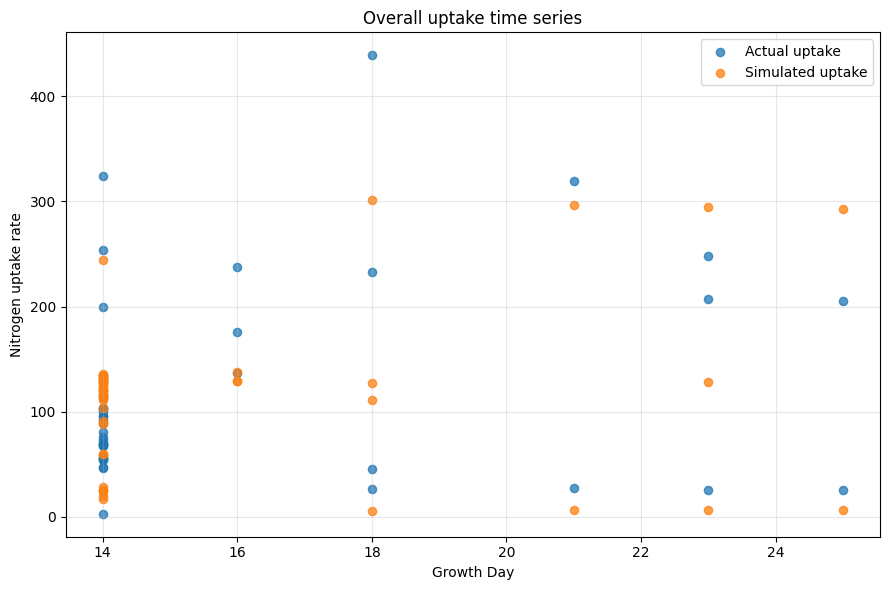

,ModRig #,Limiting Nutrient,Treatment %,Round,Treatment,Treatment mg/L N,Treatment mg/L P,Treatment mg/L K,Rig,Growth Day,...,Inst [K],Sample Period Avg [N],Sample Period Avg [P],Sample Period Avg [K],Concat (Sample to Plant),Category,N,U_obs,screen_flag,U_sim
0,161,N,0.19,R09,R09N,25.0,NaN,NaN,N2,14,...,135.014806,12.059167,37.094922,147.365245,R09-14-N2,N,17.816905,55.697207,SCREEN,19.803772
1,162,N,0.19,R09,R09N,25.0,NaN,NaN,N3,14,...,125.286841,7.555000,34.593033,134.883269,R09-14-N3,N,15.532857,46.413086,SCREEN,17.265061
2,229,N,0.50,R09,R09S,66.0,NaN,NaN,S1,14,...,126.809237,44.200000,3.406178,141.617620,R09-14-S1,N,53.971429,76.302185,SCREEN,59.987687
3,231,N,0.50,R09,R09S,66.0,NaN,NaN,S3,14,...,144.192443,48.325000,3.172830,151.722156,R09-14-S3,N,53.978571,68.362110,SCREEN,59.995626
4,370,N,2.00,R12,R11n12,264.0,NaN,NaN,S1,14,...,140.229565,220.800000,21.054394,150.802129,R12-14-S1,N,219.825000,253.753419,SCREEN,244.284120


In [83]:
time_col_candidates = ["Growth Day", "GrowthDay", "DAT", "Day"]
time_col = find_first_existing(sample_df.columns, time_col_candidates)

if time_col is None:
    raise ValueError("Could not find a time / growth day column for time-series plotting.")

uptake_ts_df = sample_df.copy()
uptake_ts_df["Treatment"] = uptake_ts_df[treatment_col].astype(str).str.strip()
uptake_ts_df["Category"] = uptake_ts_df[category_col].apply(normalize_category)
uptake_ts_df["Growth Day"] = pd.to_numeric(uptake_ts_df[time_col], errors="coerce")
uptake_ts_df["N"] = pd.to_numeric(uptake_ts_df[n_col], errors="coerce")
uptake_ts_df["U_obs"] = pd.to_numeric(uptake_ts_df[uptake_col], errors="coerce")

if screen_col is not None:
    uptake_ts_df["screen_flag"] = uptake_ts_df[screen_col].astype(str).str.strip().str.upper()
    uptake_ts_df = uptake_ts_df[uptake_ts_df["screen_flag"] == "SCREEN"].copy()

uptake_ts_df = uptake_ts_df.dropna(subset=["Growth Day", "N", "U_obs"]).copy()
uptake_ts_df = uptake_ts_df[
    np.isfinite(uptake_ts_df["Growth Day"]) &
    np.isfinite(uptake_ts_df["N"]) &
    np.isfinite(uptake_ts_df["U_obs"])
].copy()
uptake_ts_df = uptake_ts_df[(uptake_ts_df["N"] > 0) & (uptake_ts_df["U_obs"] > 0)].copy()

uptake_ts_df["U_sim"] = michaelis_menten(uptake_ts_df["N"].values, umax_fit, km_fit)
uptake_ts_df = uptake_ts_df.sort_values(["Growth Day", "Treatment"]).reset_index(drop=True)

plt.figure(figsize=(9, 6))
plt.scatter(
    uptake_ts_df["Growth Day"],
    uptake_ts_df["U_obs"],
    s=35,
    alpha=0.75,
    label="Actual uptake"
)
plt.scatter(
    uptake_ts_df["Growth Day"],
    uptake_ts_df["U_sim"],
    s=35,
    alpha=0.75,
    label="Simulated uptake"
)

plt.xlabel("Growth Day")
plt.ylabel("Nitrogen uptake rate")
plt.title("Overall uptake time series")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

uptake_ts_df.head()


In [84]:
# Save filtered data used in plotting for inspection
uptake_df.to_csv(OUTPUT_DIR / "uptake_filtered_global_fit.csv", index=False)
uptake_ts_df.to_csv(OUTPUT_DIR / "uptake_filtered_timeseries_raw.csv", index=False)
uptake_ts_mean.to_csv(OUTPUT_DIR / "uptake_filtered_timeseries_mean.csv", index=False)

print("Saved:")
print("-", OUTPUT_DIR / "uptake_filtered_global_fit.csv")
print("-", OUTPUT_DIR / "uptake_filtered_timeseries_raw.csv")
print("-", OUTPUT_DIR / "uptake_filtered_timeseries_mean.csv")


Saved:
- checkpoint2_uptake_outputs/uptake_filtered_global_fit.csv
- checkpoint2_uptake_outputs/uptake_filtered_timeseries_raw.csv
- checkpoint2_uptake_outputs/uptake_filtered_timeseries_mean.csv
